# Drilling Failure Prediction — Supervised Learning + Ensemble Methods

**Dataset:** XAI Drilling Dataset (20,000 rows, sensor readings from a drilling process)

**Goal:** Predict whether a drilling operation results in a failure (`Main Failure`) using:
1. Supervised learning models (Logistic Regression, Decision Tree, KNN)
2. Ensemble learning models (Random Forest, Gradient Boosting, XGBoost, Voting Classifier)

This dataset is a predictive-maintenance style dataset — a very natural fit for classification.


## 1. Load and explore the data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv("XAI_Drilling_Dataset.csv")
print(df.shape)
df.head()


(20000, 15)


,ID,Cutting speed vc [m/min],Spindle speed n [1/min],Feed f [mm/rev],Feed rate vf [mm/min],Power Pc [kW],Cooling [%],Material,Drill Bit Type,Process Time [sec],Main Failure,BEF,CCF,FWF,WDF
0,1,29.92,794,0.218,173,194.87,75,N,W,19.26,0,0,0,0,0
1,2,29.85,792,0.241,191,214.71,75,N,W,19.55,0,0,0,0,0
2,3,22.85,606,0.183,111,95.68,50,P,N,36.16,0,0,0,0,0
3,4,29.60,785,0.236,237,206.93,75,N,W,21.22,1,0,0,1,0
4,5,17.43,462,0.246,114,74.85,50,K,H,33.56,0,0,0,0,0


In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        20000 non-null  int64  
 1   Cutting speed vc [m/min]  20000 non-null  float64
 2   Spindle speed n [1/min]   20000 non-null  int64  
 3   Feed f [mm/rev]           20000 non-null  float64
 4   Feed rate vf [mm/min]     20000 non-null  int64  
 5   Power Pc [kW]             20000 non-null  float64
 6   Cooling [%]               20000 non-null  int64  
 7   Material                  20000 non-null  str    
 8   Drill Bit Type            20000 non-null  str    
 9   Process Time [sec]        20000 non-null  float64
 10  Main Failure              20000 non-null  int64  
 11  BEF                       20000 non-null  int64  
 12  CCF                       20000 non-null  int64  
 13  FWF                       20000 non-null  int64  
 14  WDF              

In [ ]:
df.describe()


,ID,Cutting speed vc [m/min],Spindle speed n [1/min],Feed f [mm/rev],Feed rate vf [mm/min],Power Pc [kW],Cooling [%],Process Time [sec],Main Failure,BEF,CCF,FWF,WDF
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,23.322470,618.644400,0.224831,140.629850,128.992781,56.750000,29.242184,0.050050,0.010750,0.017200,0.013900,0.015000
std,5773.647028,5.174178,137.248701,0.037563,41.470466,65.403239,23.941933,6.866544,0.218054,0.103126,0.130019,0.117079,0.121555
min,1.000000,16.330000,433.000000,0.108000,62.000000,49.040000,0.000000,15.970000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5000.750000,17.590000,467.000000,0.193000,109.000000,78.510000,50.000000,20.360000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,10000.500000,22.610000,600.000000,0.233000,122.000000,93.250000,50.000000,32.960000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,15000.250000,29.780000,790.000000,0.254000,183.000000,203.600000,75.000000,34.530000,0.000000,0.000000,0.000000,0.000000,0.000000
max,20000.000000,31.070000,824.000000,0.321000,261.000000,305.220000,100.000000,38.570000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df.isna().sum()


ID                          0
Cutting speed vc [m/min]    0
Spindle speed n [1/min]     0
Feed f [mm/rev]             0
Feed rate vf [mm/min]       0
Power Pc [kW]               0
Cooling [%]                 0
Material                    0
Drill Bit Type              0
Process Time [sec]          0
Main Failure                0
BEF                         0
CCF                         0
FWF                         0
WDF                         0
dtype: int64

No missing values — the dataset is clean. 

Target column for this task: **`Main Failure`** (0 = no failure, 1 = failure).
There are also 4 specific failure-type flags (BEF, CCF, FWF, WDF) which are sub-types of failure — 
we won't use those as inputs since they would leak the answer, but it's good to know they exist.

In [ ]:
df['Main Failure'].value_counts()


Main Failure
0    18999
1     1001
Name: count, dtype: int64

**Important observation:** the classes are imbalanced — only ~5% of rows are failures (1001 out of 20000).
This is realistic for real drilling data (failures are rare events), but it means we should NOT judge
our model on accuracy alone — we'll also look at precision, recall and F1-score, especially for the
minority (failure) class.

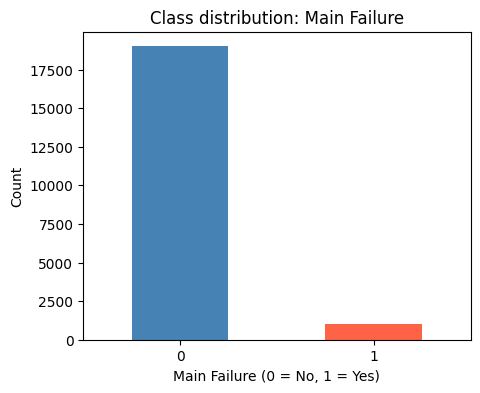

In [ ]:
plt.figure(figsize=(5,4))
df['Main Failure'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title("Class distribution: Main Failure")
plt.xlabel("Main Failure (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


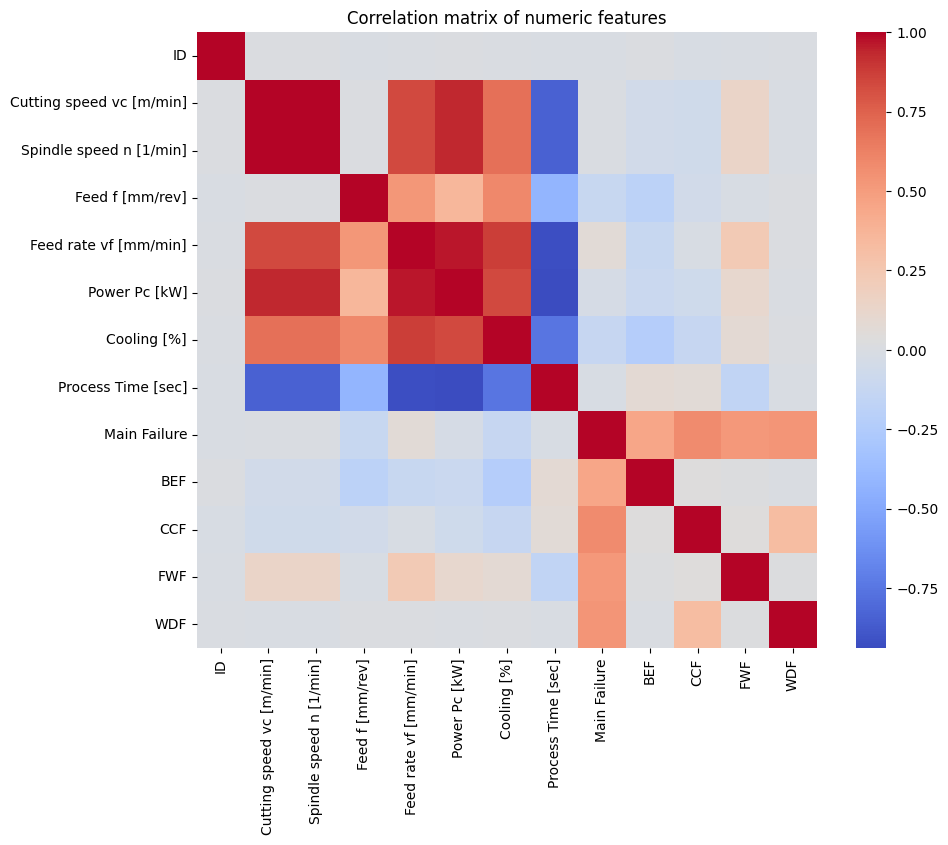

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap='coolwarm', annot=False)
plt.title("Correlation matrix of numeric features")
plt.show()


## 2. Preprocessing

- Drop the `ID` column (not a real feature)
- Drop the specific failure-type columns (BEF, CCF, FWF, WDF) since they are essentially the same information as the target, just split by failure type — keeping them would let the model "cheat"
- One-hot encode the categorical columns `Material` and `Drill Bit Type`
- Split into train/test sets
- Scale numeric features (needed for Logistic Regression / KNN)

In [8]:
X = df.drop(columns=['ID', 'Main Failure', 'BEF', 'CCF', 'FWF', 'WDF'])
y = df['Main Failure']

X = pd.get_dummies(X, columns=['Material', 'Drill Bit Type'], drop_first=True)

# Clean column names: XGBoost doesn't allow [, ], < in feature names
X.columns = (
    X.columns.str.replace('[', '(', regex=False)
             .str.replace(']', ')', regex=False)
             .str.replace('<', 'lt', regex=False)
)

X.head()


,Cutting speed vc (m/min),Spindle speed n (1/min),Feed f (mm/rev),Feed rate vf (mm/min),Power Pc (kW),Cooling (%),Process Time (sec),Material_N,Material_P,Drill Bit Type_N,Drill Bit Type_W
0,29.92,794,0.218,173,194.87,75,19.26,True,False,False,True
1,29.85,792,0.241,191,214.71,75,19.55,True,False,False,True
2,22.85,606,0.183,111,95.68,50,36.16,False,True,True,False
3,29.60,785,0.236,237,206.93,75,21.22,True,False,False,True
4,17.43,462,0.246,114,74.85,50,33.56,False,False,False,False


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Failure rate in train:", y_train.mean().round(3), " | Failure rate in test:", y_test.mean().round(3))


Train shape: (16000, 11)  Test shape: (4000, 11)
Failure rate in train: 0.05  | Failure rate in test: 0.05


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 3. Supervised Learning Models

### 3.1 Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score

log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

pred_lr = log_reg.predict(X_test_scaled)

print("Accuracy:", round(accuracy_score(y_test, pred_lr), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, log_reg.predict_proba(X_test_scaled)[:,1]), 3))
print()
print(classification_report(y_test, pred_lr))


Accuracy: 0.946
ROC-AUC: 0.851

              precision    recall  f1-score   support

           0       0.99      0.96      0.97      3800
           1       0.48      0.73      0.58       200

    accuracy                           0.95      4000
   macro avg       0.73      0.84      0.77      4000
weighted avg       0.96      0.95      0.95      4000



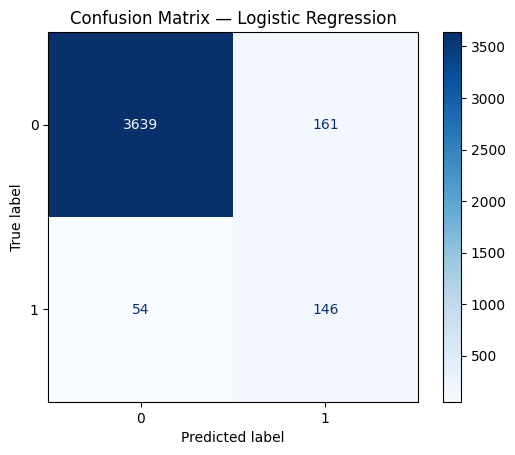

In [12]:
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_lr)).plot(cmap='Blues')
plt.title("Confusion Matrix — Logistic Regression")
plt.show()


### 3.2 Decision Tree

In [13]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42)
tree.fit(X_train, y_train)

pred_tree = tree.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, pred_tree), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, tree.predict_proba(X_test)[:,1]), 3))
print()
print(classification_report(y_test, pred_tree))


Accuracy: 0.993
ROC-AUC: 0.969

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3800
           1       0.97      0.89      0.93       200

    accuracy                           0.99      4000
   macro avg       0.98      0.94      0.96      4000
weighted avg       0.99      0.99      0.99      4000



### 3.3 K-Nearest Neighbors

In [14]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)

pred_knn = knn.predict(X_test_scaled)

print("Accuracy:", round(accuracy_score(y_test, pred_knn), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, knn.predict_proba(X_test_scaled)[:,1]), 3))
print()
print(classification_report(y_test, pred_knn))


Accuracy: 0.995


ROC-AUC: 0.997

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3800
           1       0.97      0.92      0.94       200

    accuracy                           0.99      4000
   macro avg       0.98      0.96      0.97      4000
weighted avg       0.99      0.99      0.99      4000



## 4. Ensemble Learning Models

Ensemble methods combine multiple models to get better and more stable predictions.
We'll try **bagging** (Random Forest), **boosting** (Gradient Boosting, XGBoost) and a **voting** ensemble.

### 4.1 Random Forest (Bagging)

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, pred_rf), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]), 3))
print()
print(classification_report(y_test, pred_rf))


Accuracy: 0.998
ROC-AUC: 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3800
           1       0.98      0.99      0.98       200

    accuracy                           1.00      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       1.00      1.00      1.00      4000



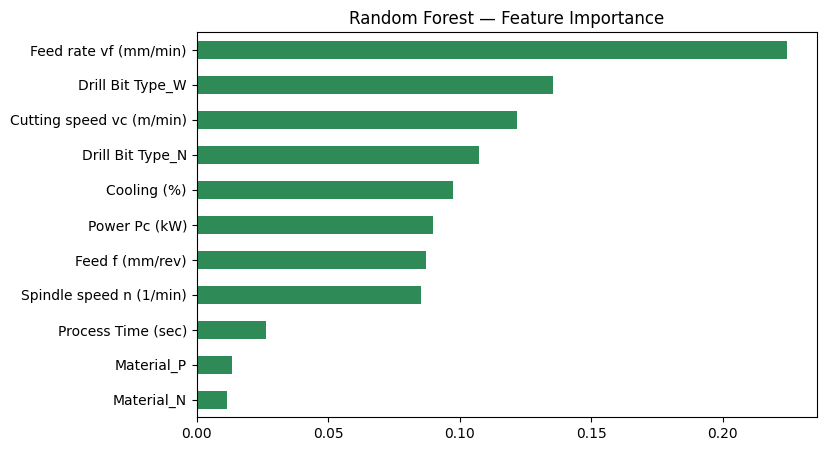

In [16]:
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(8,5))
importance.plot(kind='barh', color='seagreen')
plt.title("Random Forest — Feature Importance")
plt.show()


### 4.2 Gradient Boosting

In [17]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, pred_gb), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, gb.predict_proba(X_test)[:,1]), 3))
print()
print(classification_report(y_test, pred_gb))


Accuracy: 0.998
ROC-AUC: 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3800
           1       0.98      0.98      0.98       200

    accuracy                           1.00      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       1.00      1.00      1.00      4000



### 4.3 XGBoost

In [18]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, pred_xgb), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]), 3))
print()
print(classification_report(y_test, pred_xgb))


Accuracy: 0.999
ROC-AUC: 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3800
           1       0.98      1.00      0.99       200

    accuracy                           1.00      4000
   macro avg       0.99      1.00      0.99      4000
weighted avg       1.00      1.00      1.00      4000



### 4.4 Voting Classifier (combining models)

In [19]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=[('rf', rf), ('gb', gb), ('xgb', xgb)],
    voting='soft'
)
voting.fit(X_train, y_train)

pred_vote = voting.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, pred_vote), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, voting.predict_proba(X_test)[:,1]), 3))
print()
print(classification_report(y_test, pred_vote))


Accuracy: 0.999
ROC-AUC: 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3800
           1       0.98      0.99      0.99       200

    accuracy                           1.00      4000
   macro avg       0.99      1.00      0.99      4000
weighted avg       1.00      1.00      1.00      4000



## 5. Model Comparison

In [20]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'KNN', 'Random Forest',
              'Gradient Boosting', 'XGBoost', 'Voting Ensemble'],
    'Accuracy': [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_tree),
        accuracy_score(y_test, pred_knn),
        accuracy_score(y_test, pred_rf),
        accuracy_score(y_test, pred_gb),
        accuracy_score(y_test, pred_xgb),
        accuracy_score(y_test, pred_vote),
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, log_reg.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, tree.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, knn.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, gb.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, voting.predict_proba(X_test)[:,1]),
    ]
}).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

results


,Model,Accuracy,ROC-AUC
0,XGBoost,0.99875,0.999886
1,Voting Ensemble,0.99875,0.999864
2,Random Forest,0.99825,0.999850
3,Gradient Boosting,0.99825,0.999678
4,KNN,0.99450,0.996920
5,Decision Tree,0.99300,0.968613
6,Logistic Regression,0.94625,0.851200


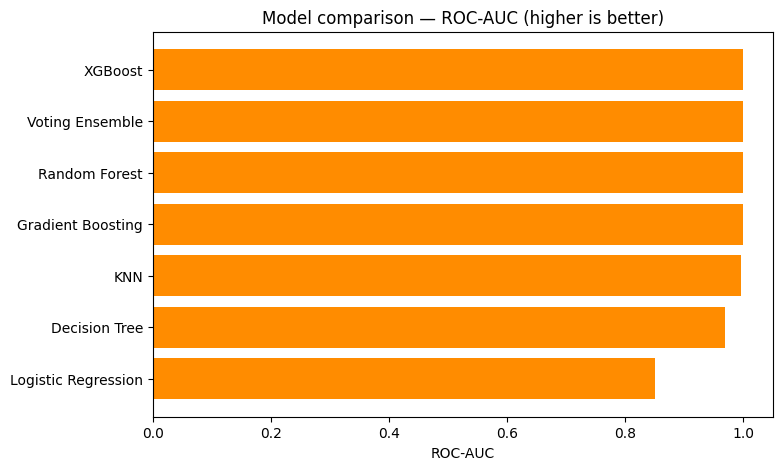

In [21]:
plt.figure(figsize=(8,5))
plt.barh(results['Model'], results['ROC-AUC'], color='darkorange')
plt.xlabel("ROC-AUC")
plt.title("Model comparison — ROC-AUC (higher is better)")
plt.gca().invert_yaxis()
plt.show()
